<a href="https://colab.research.google.com/github/Abhhiiissshhek/100_days_of_ML_challenge/blob/main/day-10-roc-auc/day10_roc_auc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# showing the total no. of missing values in the dataset
df.isnull().sum()

# showing the percentage of missing data
(df.isnull().sum() / len(df)) * 100

# Cabin is 77% missing - basically useless
df.drop('Cabin', axis=1, inplace=True)

# Age is 20% missing - fill with MEDIAN
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked is 0.2% missing - fill with MODE
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.isnull().sum().sum() # our dataset is clean now !!

# Create Family Size from SibSp + Parch
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Extract Title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Create Age Groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Create IsAlone flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

<>:28: SyntaxWarning: invalid escape sequence '\.'
<>:28: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-427/3487865981.py:28: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipython-input-427/3487865981.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-427/3487865981.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained a

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone']
X = df[features].copy()
y = df['Survived'].values

# Convert Sex to numbers
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X = X.values

print(f"✅ Total samples: {len(X)}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

✅ Total samples: 891


# **Day 10 ✈ :**

# **THE THRESHOLD PROBLEM**

* Threshold 0.3 → More positives, more false alarms
* Threshold 0.7 → Fewer positives, might miss real ones

### **THRESHOLD = PROBLEM 🤔**

# **SOLUTION: ROC CURVE**

Draw graph:
* X-axis = FPR (False Positive Rate)
* Y-axis = TPR (True Positive Rate)

* True Positive Rate (Sensitivity) = TP / (TP + FN)
* False Positive Rate (1 - Specificity) = FP / (FP + TN)

## **TPR vs FPR | ALL THRESHOLDS 📈**

# **WHAT PERFECT LOOKS LIKE**

## **Draw perfect ROC curve -**
**goes straight up then right**

Perfect Model:
* ↑ Goes to top-left corner (0,1)
* → TPR = 100%, FPR = 0%

## **PERFECT = TOP-LEFT | RANDOM = DIAGONAL 📐**

# **CODE: ROC CURVE**

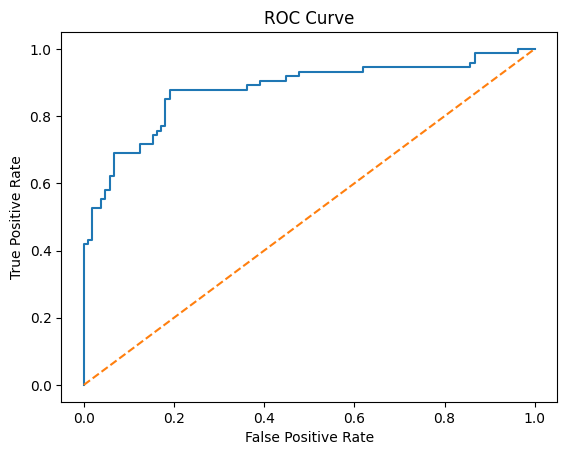

AUC: 0.878


In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')  # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.3f}")

## **AUC: 0.87**

Interpretation:
* Random survivor probability: 0.87
* Random deceased probability: 0.13
* Model is EXCELLENT at distinguishing!